# Lab 01 — Naive RAG (interactive)

chunk → embed → store → retrieve, then look at what came back.

**Before running:** `./tunnel.sh`.

In [22]:
%matplotlib inline
import sys
from pathlib import Path
p = Path.cwd()
LABS = next(d for d in [p, *p.parents] if (d / "shared").exists())
for sub in (str(LABS), str(LABS / "01_naive_rag")):
    if sub not in sys.path:
        sys.path.insert(0, sub)
print("labs root:", LABS)

labs root: /Users/savashito/Claude/Projects/AI_research/RAG/labs


## Ingest the corpus, then retrieve
`naive_rag.ingest` and `naive_rag.retrieve` are the same functions the CLI uses.

In [23]:
import naive_rag
from shared.embedder import get_embedder

embedder = get_embedder("tei")
rows = naive_rag.load_chunks()
texts = [r[2] for r in rows]
print(f"embedding {len(texts)} chunks with '{embedder.name}' ({embedder.dim}d)...")
vectors = embedder.encode(texts)

with naive_rag.connect() as conn, conn.cursor() as cur:
    # Recreate the table to match this embedder's dimension.
    cur.execute(f"DROP TABLE IF EXISTS {naive_rag.TABLE}")
    cur.execute(
        f"""
        CREATE TABLE {naive_rag.TABLE} (
            id           bigserial PRIMARY KEY,
            source       text,
            chunk_index  int,
            text         text,
            model        text,
            embedding    vector({embedder.dim})
        )
        """
    )
    cur.executemany(
        f"INSERT INTO {naive_rag.TABLE} (source, chunk_index, text, model, embedding) "
        f"VALUES (%s, %s, %s, %s, %s)",
        [
            (src, idx, txt, embedder.name, vec)
            for (src, idx, txt), vec in zip(rows, vectors)
        ],
    )
    conn.commit()
print(f"✓ stored {len(rows)} chunks in '{naive_rag.TABLE}'.")


embedding 10 chunks with 'tei:Qwen/Qwen3-Embedding-0.6B' (1024d)...
✓ stored 10 chunks in 'chunks'.


In [30]:
q = "what is Retrieval Augmented generated?"
rows = naive_rag.retrieve(embedder, q, k=5)
for i, (src, idx, text, dist) in enumerate(rows, 1):
    print(f"[{i}] dist={dist:.3f}  {src}#{idx}: {text[:80]}...")

[1] dist=0.331  rag_basics.md#0: # A tiny knowledge base about RAG Embeddings are lists of numbers that represent...
[2] dist=0.416  rag_basics.md#6: cannot match "car" to "automobile", but it is unbeatable when the exact token mu...
[3] dist=0.443  rag_basics.md#9: Feeding a model only a few relevant chunks, instead of stuffing an entire corpus...
[4] dist=0.457  rag_basics.md#4: Hybrid retrieval combines keyword search, such as BM25, with dense vector search...
[5] dist=0.473  rag_basics.md#8: to the original text and its metadata, a single SQL query can filter by user or ...


## Visualise the distances

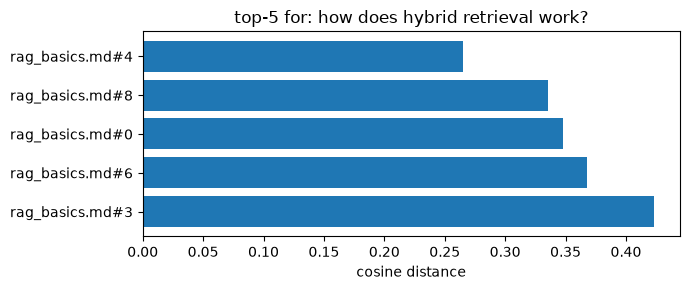

In [26]:
import matplotlib.pyplot as plt

labels = [f"{s}#{i}" for s, i, _, _ in rows]
d = [float(r[3]) for r in rows]
plt.figure(figsize=(7, 3))
plt.barh(range(len(d)), d)
plt.yticks(range(len(d)), labels)
plt.gca().invert_yaxis()
plt.xlabel("cosine distance")
plt.title(f"top-5 for: {q}")
plt.tight_layout()
plt.show()

Try an **unanswerable** question (e.g. "what is the capital of France?") — naive RAG still returns its closest chunks with high distance. It never says "I don't know." That gap motivates Labs 06–07.